# FLOOD RISK PREDICTION

## 1.Problem Definition
Flooding is one of the most devastating natural disasters, often resulting in loss of life, displacement, and destruction of property and infrastructure. Accurate and timely flood risk prediction is critical for disaster preparedness, urban planning, and climate resilience efforts. 

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

## 2. Data Collection & Understanding
What data do we have?
Let's load the data and take a look at its structure.

In [10]:
# Load the data
df = pd.read_csv('flood.csv')

# Display the first few rows
df.head(20)


,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,3,8,6,6,4,4,6,2,3,2,...,10,7,4,2,3,4,3,2,6,0.450
1,8,4,5,7,7,9,1,5,5,4,...,9,2,6,2,1,1,9,1,3,0.475
2,3,10,4,1,7,5,4,7,4,9,...,7,4,4,8,6,1,8,3,6,0.515
3,4,4,2,7,3,4,1,4,6,4,...,4,2,6,6,8,8,6,6,10,0.520
4,3,7,5,2,5,8,5,2,7,5,...,7,6,5,3,3,4,4,3,4,0.475
5,6,6,6,4,6,4,3,1,3,5,...,10,5,9,5,5,7,3,3,2,0.470
6,6,7,4,5,5,5,4,8,8,4,...,8,4,5,4,7,7,5,4,8,0.570
7,7,3,5,5,6,6,6,7,6,5,...,4,6,9,7,10,6,5,4,5,0.585
8,6,3,5,4,5,11,3,2,9,7,...,2,8,7,5,4,9,6,5,7,0.580
9,4,3,5,6,2,3,7,7,10,4,...,7,6,5,6,7,5,7,4,8,0.555


## 3. Data Preprocessing
### Cleaning and preparing the data
We'll check for missing values, data types, and basic statistics. We'll also encode categorical variables if necessary.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   MonsoonIntensity                 50000 non-null  int64  
 1   TopographyDrainage               50000 non-null  int64  
 2   RiverManagement                  50000 non-null  int64  
 3   Deforestation                    50000 non-null  int64  
 4   Urbanization                     50000 non-null  int64  
 5   ClimateChange                    50000 non-null  int64  
 6   DamsQuality                      50000 non-null  int64  
 7   Siltation                        50000 non-null  int64  
 8   AgriculturalPractices            50000 non-null  int64  
 9   Encroachments                    50000 non-null  int64  
 10  IneffectiveDisasterPreparedness  50000 non-null  int64  
 11  DrainageSystems                  50000 non-null  int64  
 12  CoastalVulnerabili

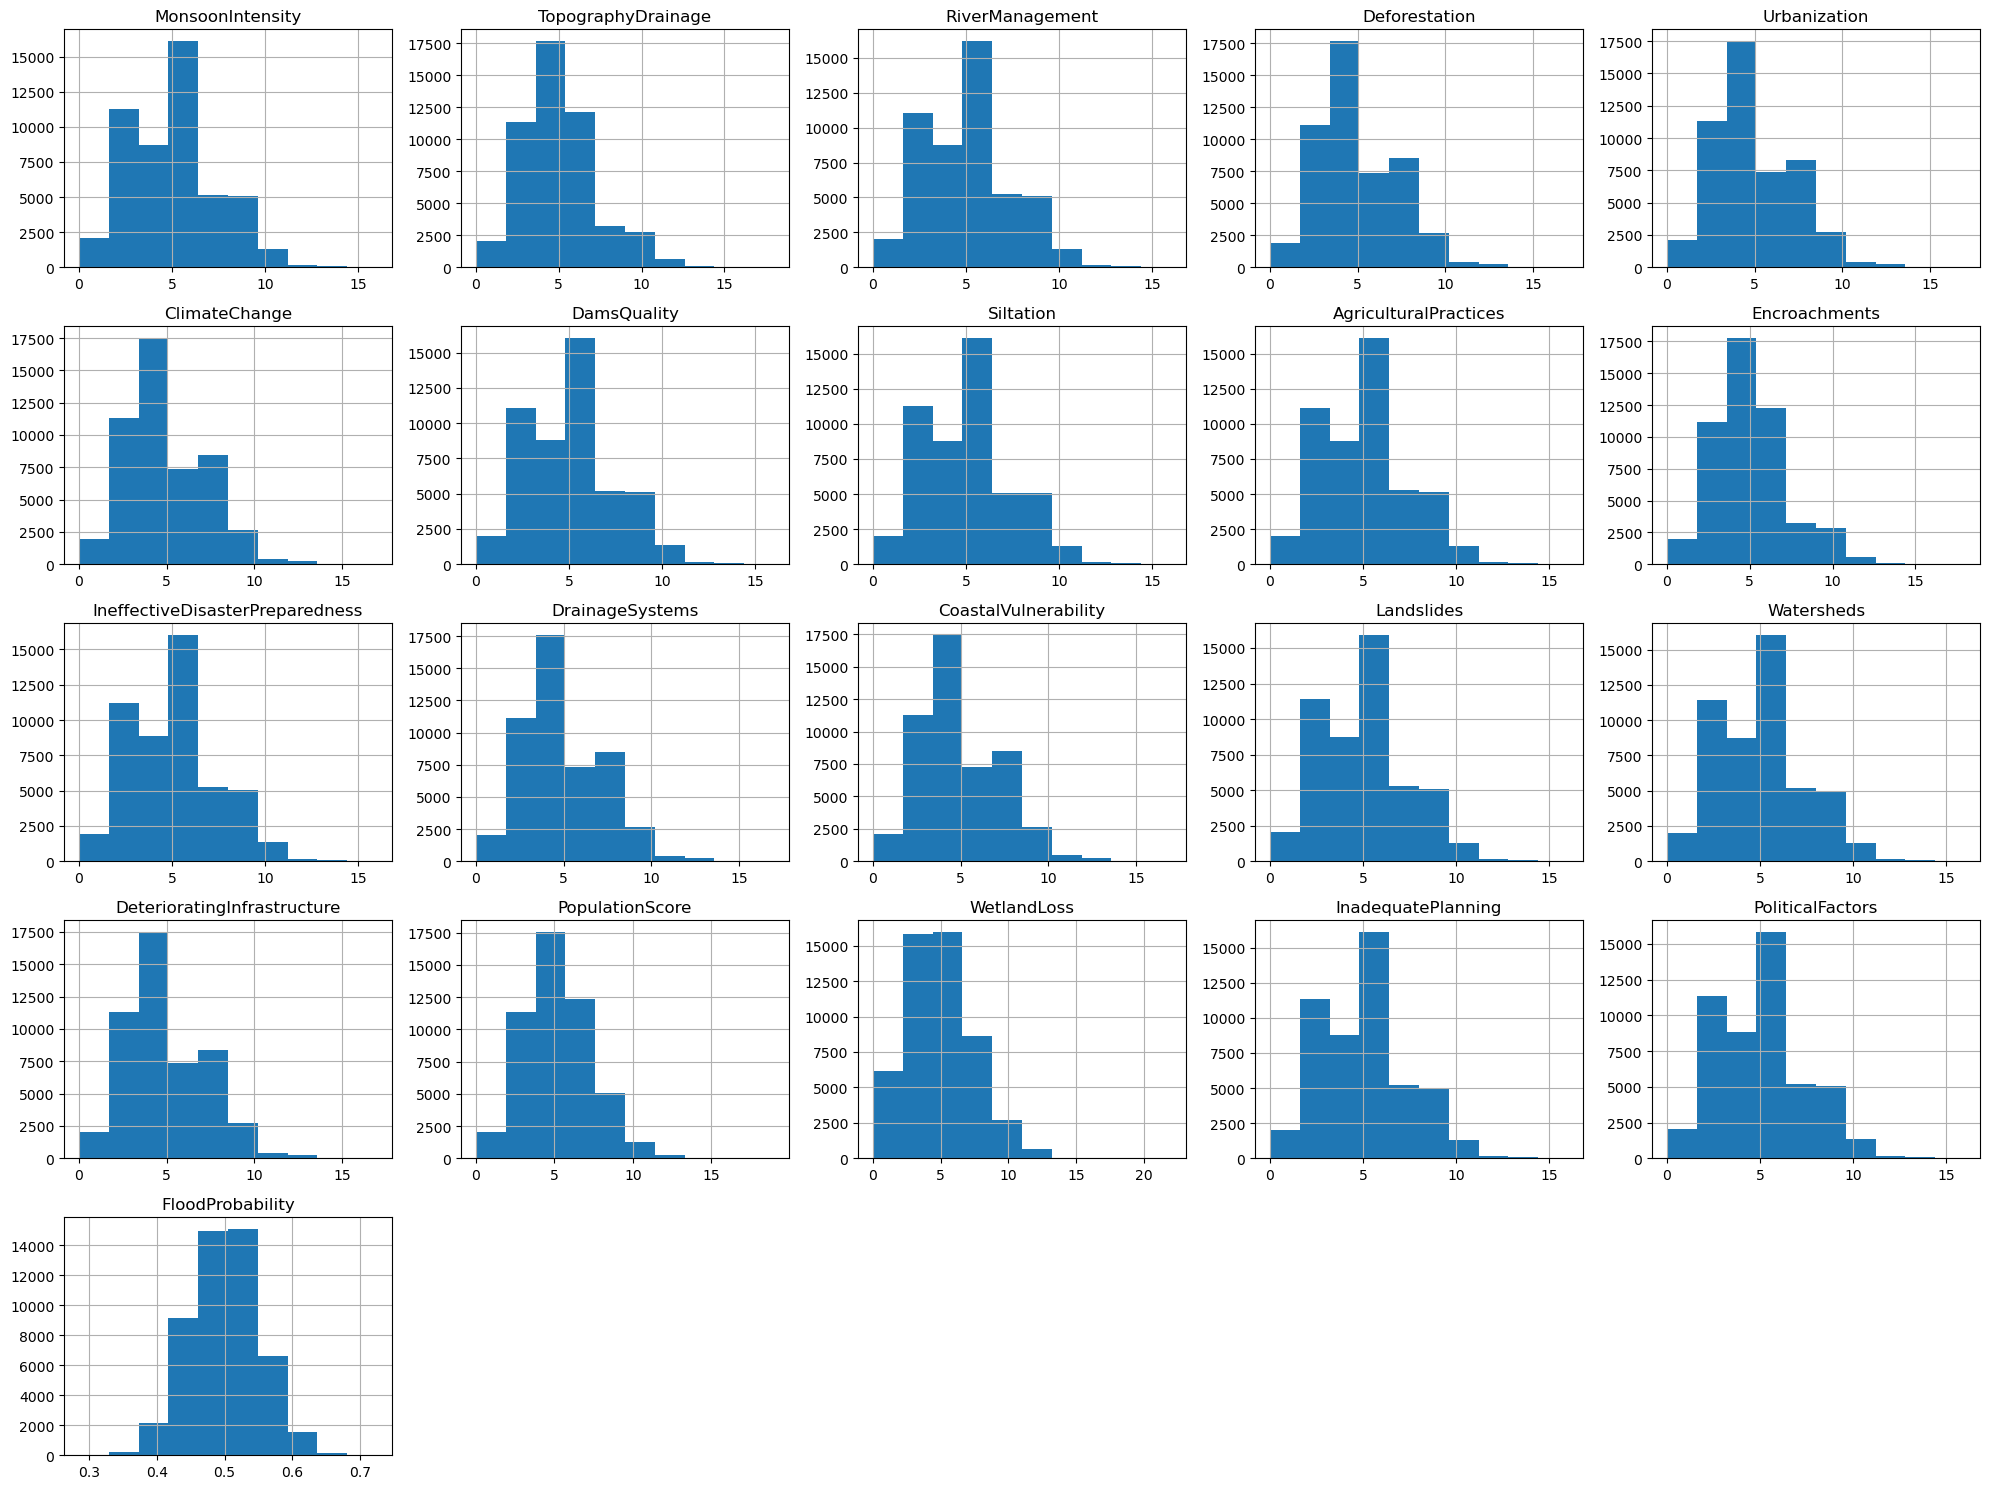

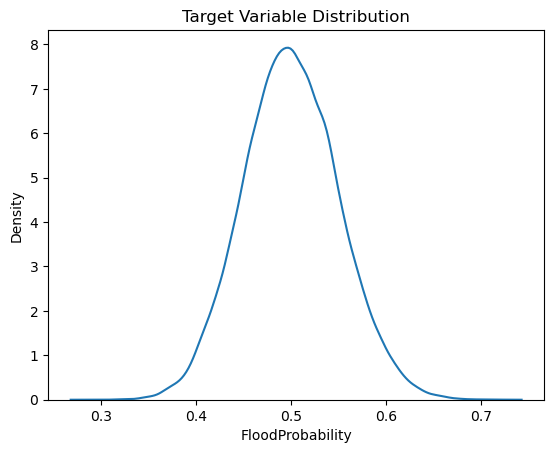

In [12]:
#Check for missing values and data types
print(df.info())

# Display basic statistics
print("THE DESCRIPTIVE STATISTICS OF THE DATASET:\n")
print(df.describe())

# Check missing values
print("MISSING VALUES:\n", df.isnull().sum())

# Verify feature distributions
df.hist(figsize=(20, 15))
plt.tight_layout()
plt.show()

# Check for class imbalance in target (though continuous)
sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.show()

In [14]:

import smogn

# Ensure all columns are numeric and handle errors
df = df.apply(pd.to_numeric, errors='coerce')

# Drop rows with NaN or infinite values
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# 1. Define your custom relevance function settings
relevance_config = [
    {
        'x': 0.4,
        'y': 1.0,
        's': 0.01
    },
    {
        'x': 0.5,
        'y': 0.0,
        's': 0.01
    },
    {
        'x': 0.6,
        'y': 1.0,
        's': 0.01
    }
]

# 2. Apply SMOGN with custom relevance
df_smogn = smogn.smoter(
    data=df,
    y='FloodProbability',
    rel_thres=0.8,
    rel_method='manual',
    rel_ctrl_pts_rg=relevance_config,
    samp_method='extreme',
    k=5
)

print("Original shape:", df.shape)
print("SMOGN-balanced shape:", df_smogn.shape)

# Use the new dataframe for training
df = df_smogn.copy()


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

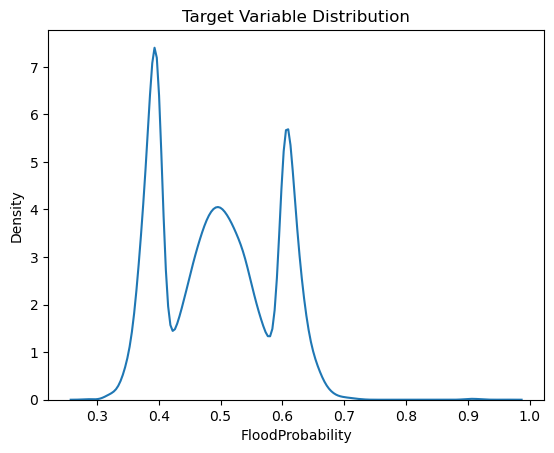

In [5]:
sns.kdeplot(df['FloodProbability'])
plt.title('Target Variable Distribution')
plt.show()

In [20]:
# ====== ADVANCED FEATURE ENGINEERING ======
# 1. Interaction terms (domain knowledge-based)
df['Monsoon_Drainage_Interaction'] = df['MonsoonIntensity'] * df['DrainageSystems']
df['Urbanization_Encroachment'] = df['Urbanization'] * df['Encroachments']

# 2. Climate vulnerability index
climate_features = ['ClimateChange', 'CoastalVulnerability', 'WetlandLoss']
df['ClimateVulnerability'] = df[climate_features].mean(axis=1)

# 3. Infrastructure quality composite
infra_features = ['RiverManagement', 'DamsQuality', 'DrainageSystems']
df['InfrastructureQuality'] = df[infra_features].mean(axis=1)


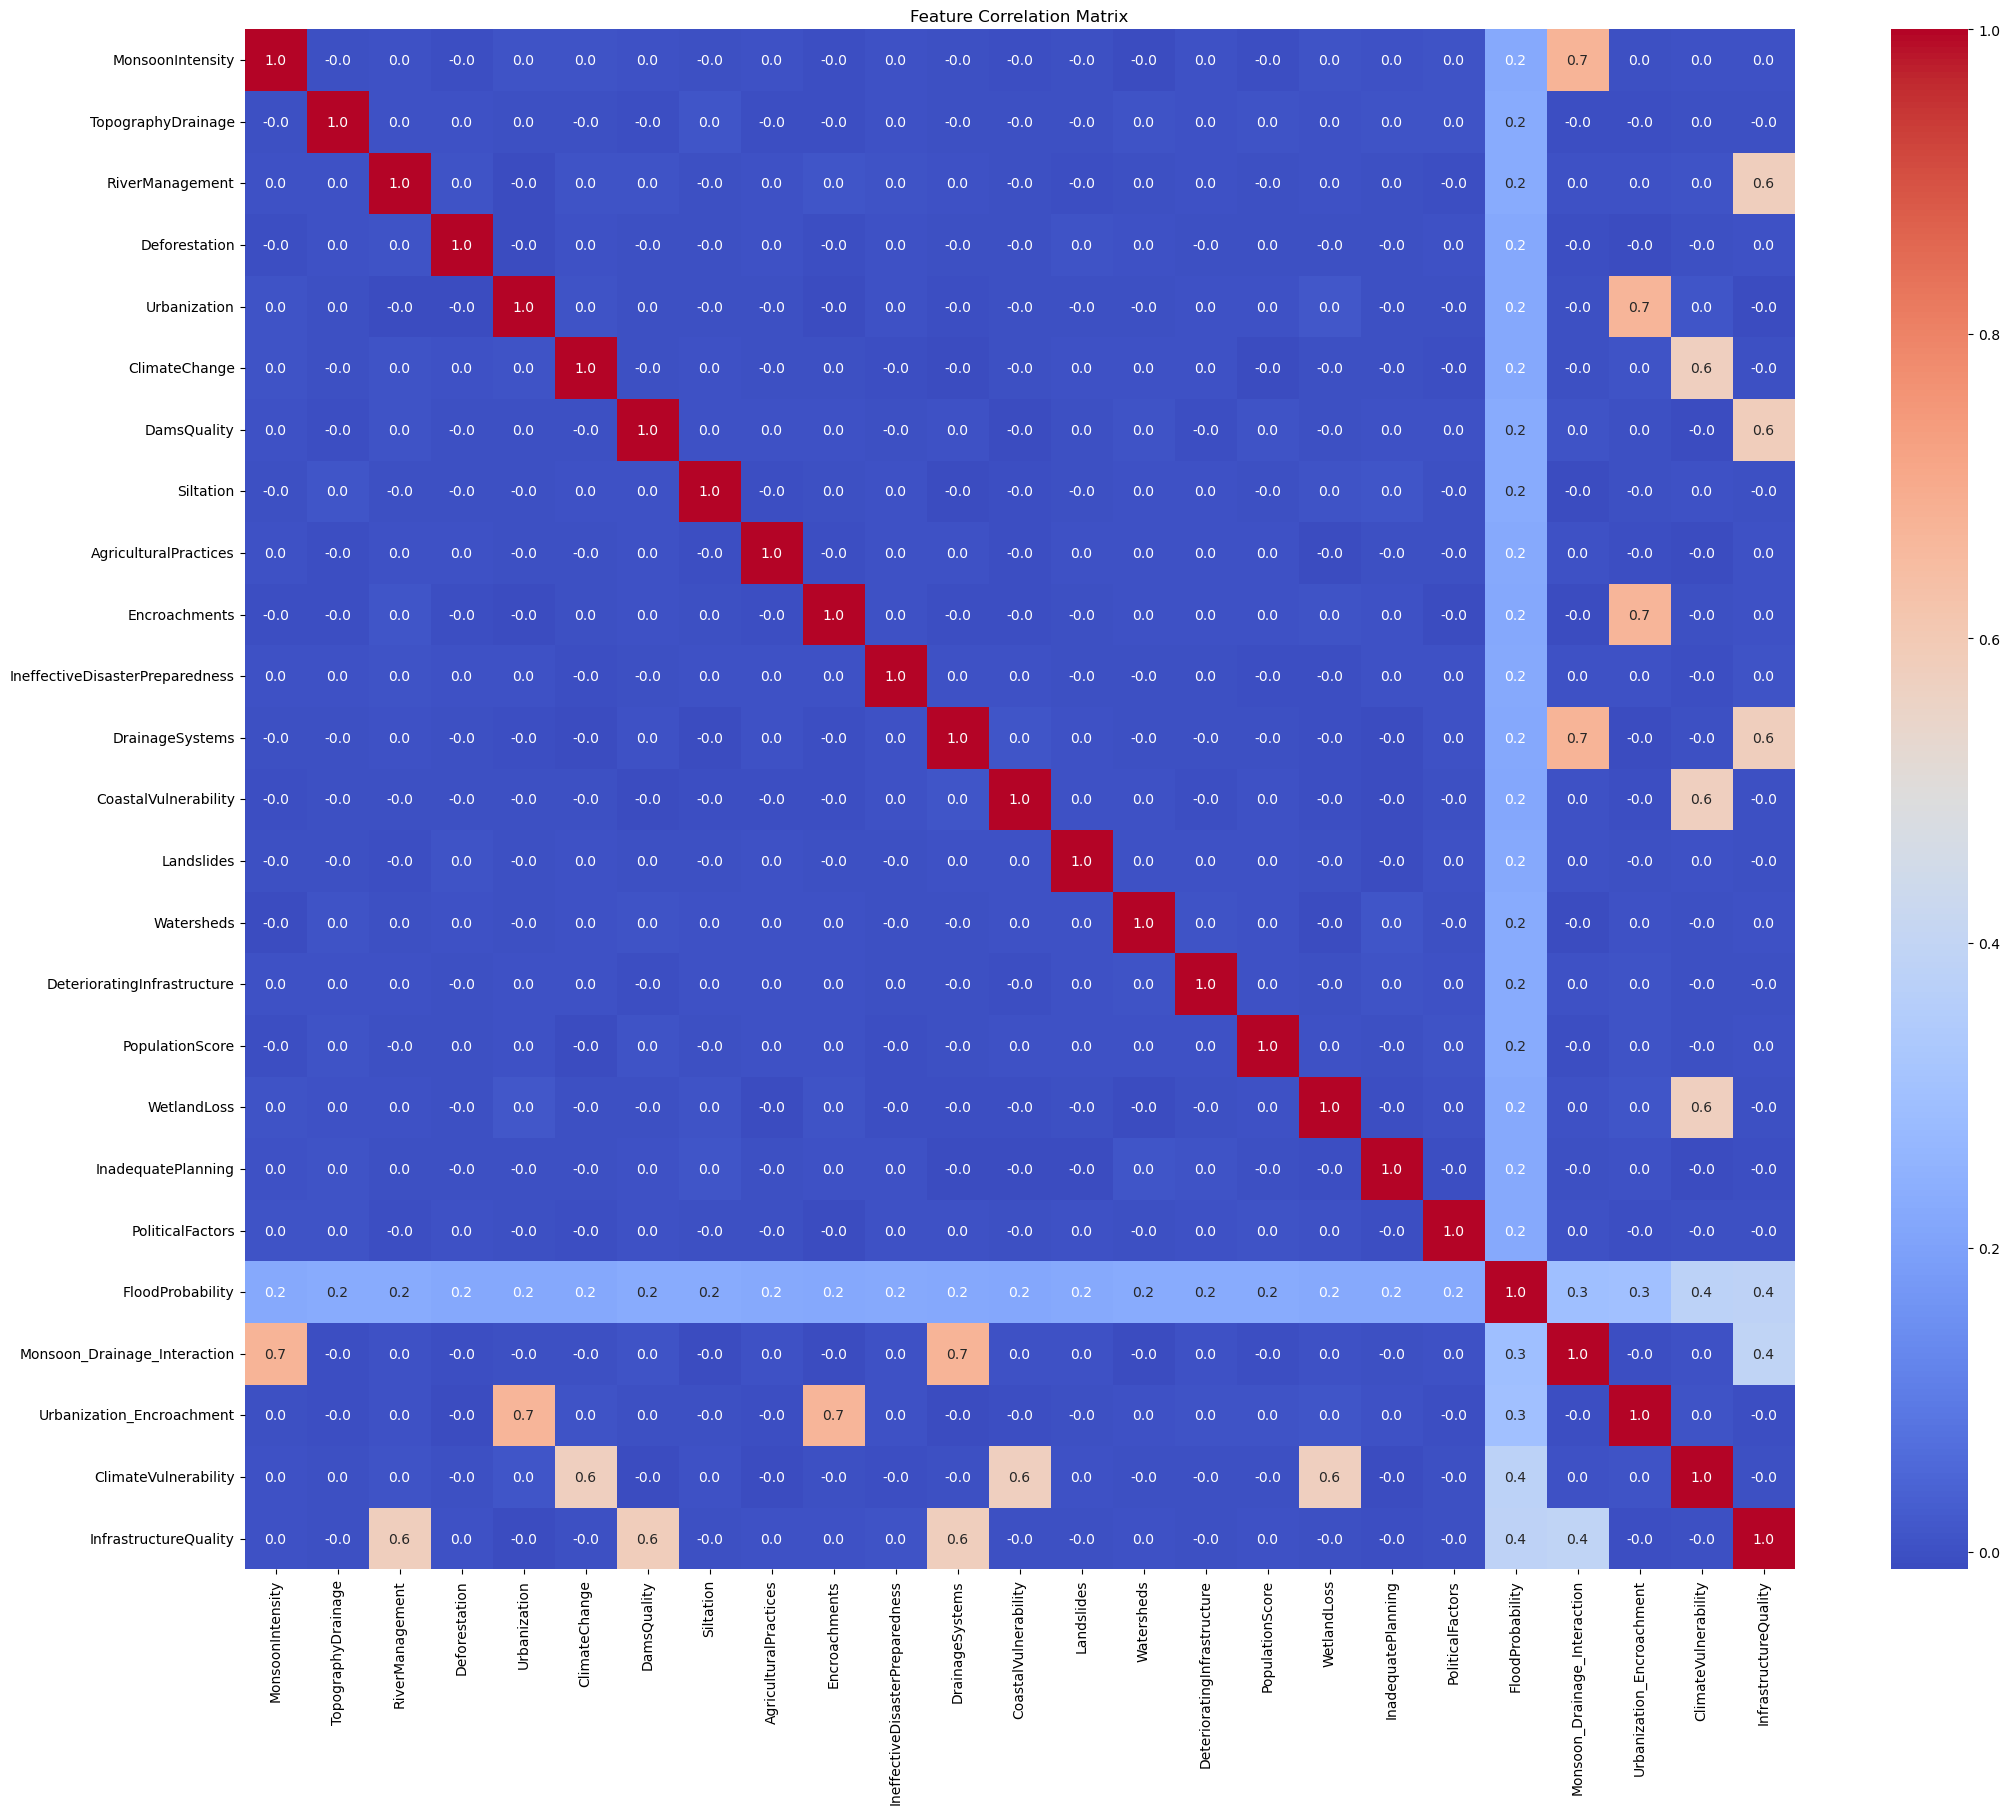

Top features by correlation:
 FloodProbability                1.000000
InfrastructureQuality           0.387482
ClimateVulnerability            0.382139
Urbanization_Encroachment       0.297995
Monsoon_Drainage_Interaction    0.296578
DeterioratingInfrastructure     0.229444
TopographyDrainage              0.229414
RiverManagement                 0.228917
Watersheds                      0.228152
DamsQuality                     0.227467
Name: FloodProbability, dtype: float64


In [21]:
# ====== CORRELATION ANALYSIS ======
plt.figure(figsize=(25, 20))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Top features by target correlation
target_corr = corr_matrix['FloodProbability'].abs().sort_values(ascending=False)
print("Top features by correlation:\n", target_corr.head(10))


In [22]:

# ====== DATA SPLITTING ======
# from sklearn.model_selection import train_test_split

X = df.drop('FloodProbability', axis=1)
y = df['FloodProbability']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:

# ==== Model Comparison ====
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
#from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

# Define RMSE scorer
rmse_scorer = make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
                          greater_is_better=False)

models = {
    'Ridge Regression': Ridge(alpha=1.0),
    'Support Vector Machine': SVR(C=1.0, kernel='rbf'),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    rmse = -cross_val_score(pipeline, X_train, y_train, cv=5, scoring=rmse_scorer).mean()
    r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2').mean()
    results.append((name, rmse, r2))
    print(f"{name}: RMSE = {rmse:.4f}, R² = {r2:.4f}")

# Create a DataFrame for easy comparison
comparison_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R2']).sort_values(by='RMSE')
print("\nModel Comparison Summary:")
print(comparison_df)

# Select best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\nBest Model Selected: {best_model_name}")

# Retrain best model
final_model = models[best_model_name]
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', final_model)
])
final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

# Evaluate final model
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)
print(f"Final Model Performance - RMSE: {final_rmse:.4f}, R²: {final_r2:.4f}")


Ridge Regression: RMSE = 0.0000, R² = 1.0000
Support Vector Machine: RMSE = 0.0272, R² = 0.7057


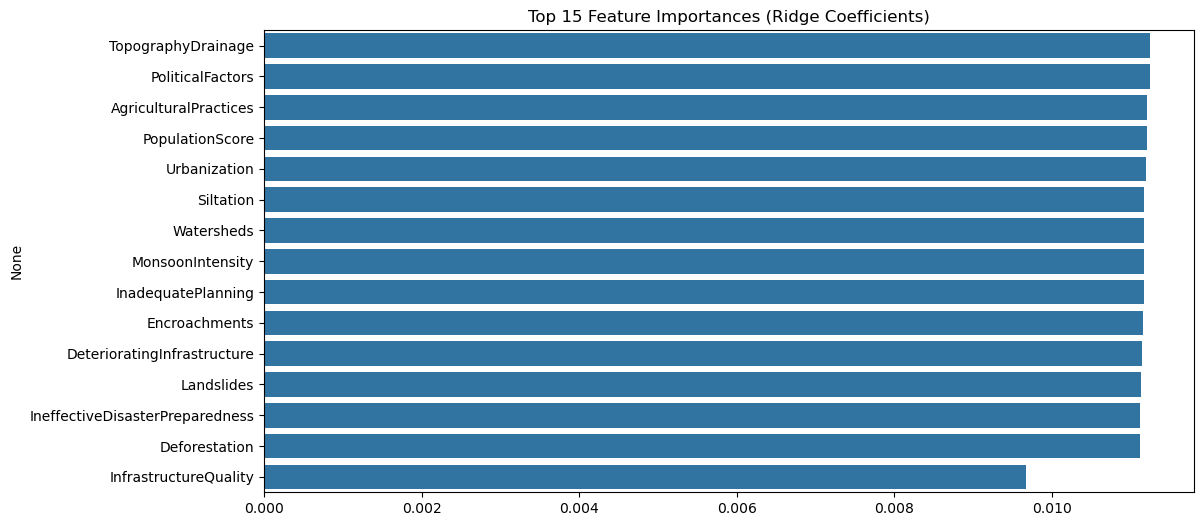

In [ ]:

# ====== FEATURE IMPORTANCE ======
# For Ridge Regression, use absolute value of coefficients as importance
importances = np.abs(final_pipeline.named_steps['model'].coef_)
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
plt.title('Top 15 Feature Importances (Ridge Coefficients)')
plt.show()

In [ ]:

# ==== Flood Probability Categorization ====

def categorize_risk(prob):
    if prob < 0.3:
        return 'Low'
    elif prob < 0.6:
        return 'Moderate'
    else:
        return 'High'

# Apply categorization to predictions
y_test_cat = y_test.apply(categorize_risk)
y_pred_cat = pd.Series(y_pred).apply(categorize_risk)

# Classification report
from sklearn.metrics import confusion_matrix, classification_report
print("Confusion Matrix:")
print(confusion_matrix(y_test_cat, y_pred_cat))
print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_cat))


Confusion Matrix:
[[ 219   47]
 [   0 9734]]

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.82      0.90       266
    Moderate       1.00      1.00      1.00      9734

    accuracy                           1.00     10000
   macro avg       1.00      0.91      0.95     10000
weighted avg       1.00      1.00      1.00     10000

